# **Student Mental Health & Burnout Prediction**

**Deskripsi Proyek**

Proyek ini mengimplementasikan **teknik Ensemble Learning** untuk memprediksi tingkat **burnout pada mahasiswa** berdasarkan faktor akademik, psikologis, dan gaya hidup. Mengikuti alur kerja sistematis yang dimulai dari analisis karakteristik error, desain arsitektur ensemble, hyperparameter tuning, validasi ketat, hingga interpretasi model menggunakan **XAI (Explainable AI)**.

**Tujuan Utama**

1. **Membangun model prediktif** yang akurat untuk mengklasifikasikan burnout level mahasiswa (Low, Medium, High)
2. **Membandingkan 3 arsitektur ensemble**: Bagging (Random Forest), Boosting (XGBoost), dan Stacking
3. **Mengidentifikasi faktor-faktor** yang paling berkontribusi terhadap burnout menggunakan SHAP & LIME
4. **Memberikan interpretasi yang transparan** untuk setiap prediksi model

**Metodologi**

| Langkah | Aktivitas | Teknik yang Digunakan |
|---------|-----------|----------------------|
| **1** | Analisis Karakteristik Data & Error | Decision Tree baseline untuk diagnosa Bias vs Variance |
| **2** | Desain Arsitektur Ensemble | Random Forest (Bagging), XGBoost (Boosting), Stacking |
| **3** | Training & Tuning Hyperparameter | GridSearchCV, Learning rate, Max depth, N_estimators |
| **4** | Validasi Ketat | Stratified K-Fold (5-fold), OOB Score |
| **5** | Interpretasi Model | SHAP values, LIME (Local Explanations) |

**Dataset**

### Sumber Data
- **Nama**: Student Mental Health and Burnout Dataset
- **Link**: [Kaggle - Student Mental Health and Burnout](https://www.kaggle.com/datasets/sehaj1104/student-mental-health-and-burnout-dataset)
- **Jumlah**: 150,000 baris × 20 fitur
- **Status**: Dataset sintetis untuk tujuan edukasi dan research

### Fitur Dataset

| Kategori | Fitur | Tipe Data |
|----------|-------|-----------|
| **Demografis** | age, gender, course, year | Kategorikal/Numerik |
| **Akademik** | CGPA, attendance, study hours | Numerik |
| **Psikologis** | anxiety_score, depression_score, stress_level | Numerik |
| **Lifestyle** | sleep_hours, physical_activity, screen_time | Numerik |
| **Sosial** | financial_stress, social_support | Numerik |
| **Target** | **burnout_level** (Low/Medium/High) | Kategorikal |

**Setup Environtment**

In [1]:
!pip install xgboost shap lime

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

import shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=b32dca737d0bf1c59ec09948a2012441f533885034b78a26632f1fe719175242
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


**Download dan Load Dataset**

In [2]:
import kagglehub

print("Mendownload dataset dari Kaggle...")
path = kagglehub.dataset_download("sehaj1104/student-mental-health-and-burnout-dataset")
df = pd.read_csv(f"{path}/student_mental_health_burnout.csv")

print(f"Dataset berhasil dimuat!")
print(f"Bentuk dataset: {df.shape[0]} baris × {df.shape[1]} kolom")
print(f"\n5 data pertama:")
df.head()

Mendownload dataset dari Kaggle...


100%|██████████| 3.24M/3.24M [00:00<00:00, 48.6MB/s]

Extracting files...


Dataset berhasil dimuat!
Bentuk dataset: 150000 baris × 20 kolom

5 data pertama:


,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


**Informasi Dataset**

In [3]:
print("="*50)
print("INFORMASI DATASET")
print("="*50)
print("\nTipe data setiap kolom:")
print(df.dtypes)

print("\nStatistik deskriptif fitur numerik:")
display(df.describe())

print("\nCek missing values:")
print(df.isnull().sum())

print("\nDistribusi target variable (burnout_level):")
print(df['burnout_level'].value_counts())
print(f"\nPersentase:\n{df['burnout_level'].value_counts(normalize=True) * 100}")

INFORMASI DATASET

Tipe data setiap kolom:
student_id                   int64
age                          int64
gender                      object
course                      object
year                        object
daily_study_hours          float64
daily_sleep_hours          float64
screen_time_hours          float64
stress_level                object
anxiety_score                int64
depression_score             int64
academic_pressure_score      int64
financial_stress_score       int64
social_support_score         int64
physical_activity_hours    float64
sleep_quality               object
attendance_percentage      float64
cgpa                       float64
internet_quality            object
burnout_level               object
dtype: object

Statistik deskriptif fitur numerik:


,student_id,age,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,attendance_percentage,cgpa
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,175000.500000,21.000380,5.507869,6.499361,6.502819,5.493907,5.497360,5.507427,5.496027,5.516060,0.998115,75.009528,6.997389
std,43301.414527,2.581216,2.595592,1.443859,3.178948,2.872607,2.869022,2.875524,2.864698,2.870493,0.578866,14.409510,1.732180
min,100001.000000,17.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,50.000000,4.000000
25%,137500.750000,19.000000,3.300000,5.200000,3.700000,3.000000,3.000000,3.000000,3.000000,3.000000,0.500000,62.500000,5.500000
50%,175000.500000,21.000000,5.500000,6.500000,6.500000,5.000000,5.000000,6.000000,6.000000,6.000000,1.000000,75.000000,6.990000
75%,212500.250000,23.000000,7.700000,7.700000,9.300000,8.000000,8.000000,8.000000,8.000000,8.000000,1.500000,87.500000,8.500000
max,250000.000000,25.000000,10.000000,9.000000,12.000000,10.000000,10.000000,10.000000,10.000000,10.000000,2.000000,100.000000,10.000000



Cek missing values:
student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64

Distribusi target variable (burnout_level):
burnout_level
Low       50265
Medium    49969
High      49766
Name: count, dtype: int64

Persentase:
burnout_level
Low       33.510000
Medium    33.312667
High      33.177333
Name: proportion, dtype: float64


**Korelasi Fitur**

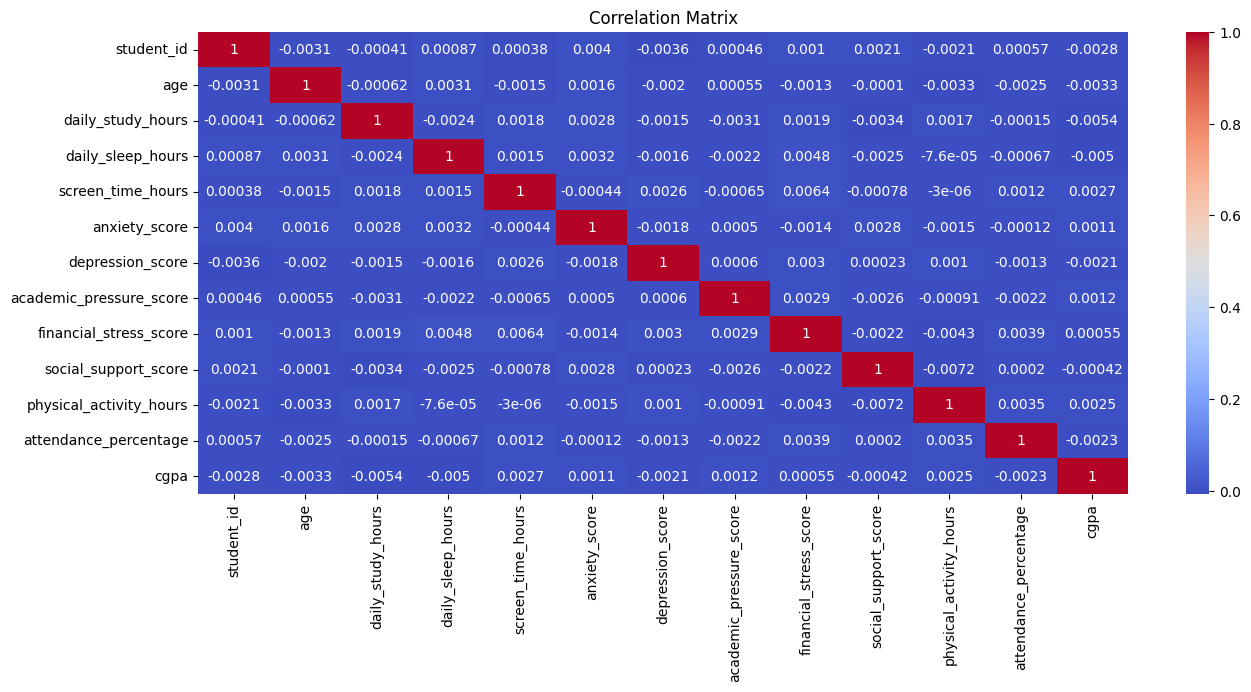

In [4]:
plt.figure(figsize=(15,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Preprocessing Data**

In [5]:
# Handle missing (opsional)
df = df.dropna()

# Encoding kategori
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,1,3,0,4.3,6.8,6.1,0,10,3,4,2,6,1.8,0,66.5,9.63,1,0
1,100002,20,1,3,2,1.4,4.7,3.0,0,2,10,8,5,9,1.9,2,55.8,6.04,2,1
2,100003,24,0,1,3,3.7,4.8,1.5,1,2,7,8,6,3,0.8,1,85.0,8.31,1,0
3,100004,21,1,2,3,1.6,6.7,7.0,0,3,3,4,9,9,0.7,2,89.1,5.95,1,0
4,100005,23,2,2,3,2.0,6.7,5.4,0,7,7,6,4,4,1.7,1,58.7,8.51,1,1


**Spit Data Train-Test**

In [6]:
X = df.drop('burnout_level', axis=1)
y = df['burnout_level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (120000, 19)
Test: (30000, 19)


**Desain Arsitektur Model Ensemble**

In [7]:
# Bagging
rf = RandomForestClassifier(random_state=42)

# Boosting
xgb = XGBClassifier(eval_metric='logloss', random_state=42)

**Training dan Tuning Hyperparameter**

In [ ]:
param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid_rf = GridSearchCV(
    rf,
    param_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best RF:", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

**Tuning menggunakan XGBoost**

In [ ]:
param_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 6]
}

grid_xgb = GridSearchCV(
    xgb,
    param_xgb,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best XGB:", grid_xgb.best_params_)
best_xgb = grid_xgb.best_estimator_

**Training dan Evaluasi Stack Model**

In [ ]:
stack_model = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('xgb', best_xgb)
    ],
    final_estimator=LogisticRegression()
)
stack_model.fit(X_train, y_train)

y_pred = stack_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

**Confusion Matrix**

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Validasi dengan K-Fold**

In [ ]:
skf = StratifiedKFold(n_splits=5)

scores = []

for train_idx, val_idx in skf.split(X, y):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    stack_model.fit(X_tr, y_tr)
    y_val_pred = stack_model.predict(X_val)

    acc = accuracy_score(y_val, y_val_pred)
    scores.append(acc)

print("K-Fold Accuracy:", scores)
print("Mean Accuracy:", np.mean(scores))

**Interpretasi Model Menggunakan XAI**

In [ ]:
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

**Feature Importance**

In [ ]:
importances = best_rf.feature_importances_

feat_importance = pd.Series(importances, index=X.columns)
feat_importance.nlargest(10).plot(kind='barh')

plt.title("Top 10 Feature Importance")
plt.show()